In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pyprojroot import here

In [25]:
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [26]:
df = pd.read_csv(PROCESSED_DATA_DIR/"RELMS_index.csv")

In [27]:
relms = df["RELMS_index"].to_numpy()
relm = df["RELM_index"].to_numpy()
diff = relms - relm  # RELMS - RELM

n = len(diff)
print(f"N pairs: {n}")
print(f"Mean diff: {diff.mean():.6f}")
print(f"Median diff: {np.median(diff):.6f}")
print(f"SD diff: {diff.std(ddof=1):.6f}")

N pairs: 2478
Mean diff: 0.035829
Median diff: 0.049811
SD diff: 0.050523


### RELM and RELMS distribution

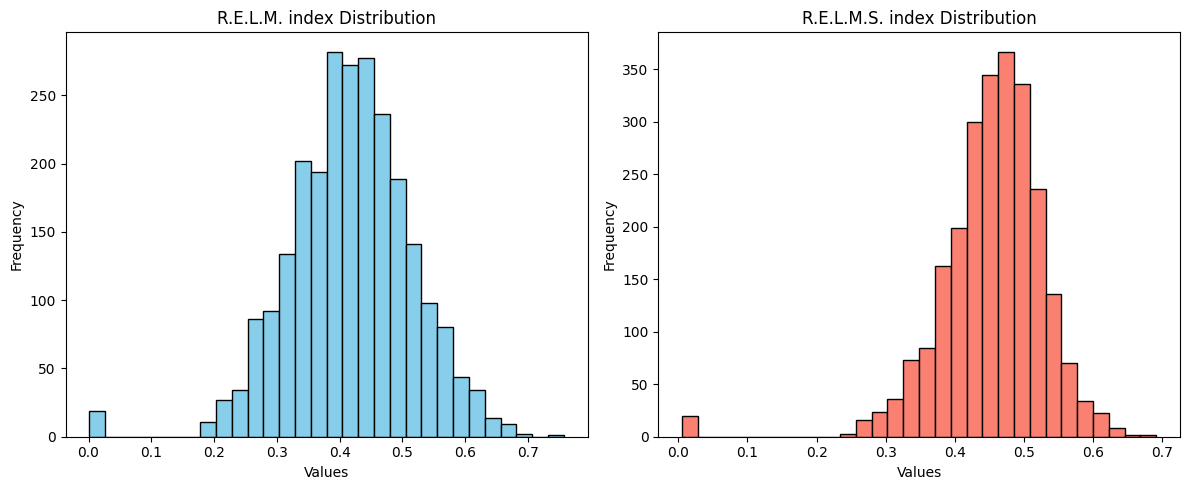

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(relm, bins=30, color='skyblue', edgecolor='black')
ax1.set_title('R.E.L.M. index Distribution')
ax1.set_xlabel('Values')
ax1.set_ylabel('Frequency')

ax2.hist(relms, bins=30, color='salmon', edgecolor='black')
ax2.set_title('R.E.L.M.S. index Distribution')
ax2.set_xlabel('Values')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/"inferential/relms_relm_distribution.png", dpi=150)
plt.show()


### Shapiro-wilks normality test


--- Shapiro-Wilk normality test on differences ---
W = 0.7700, p = 0.000000
-> Differences deviate significantly from normality (favor Wilcoxon).


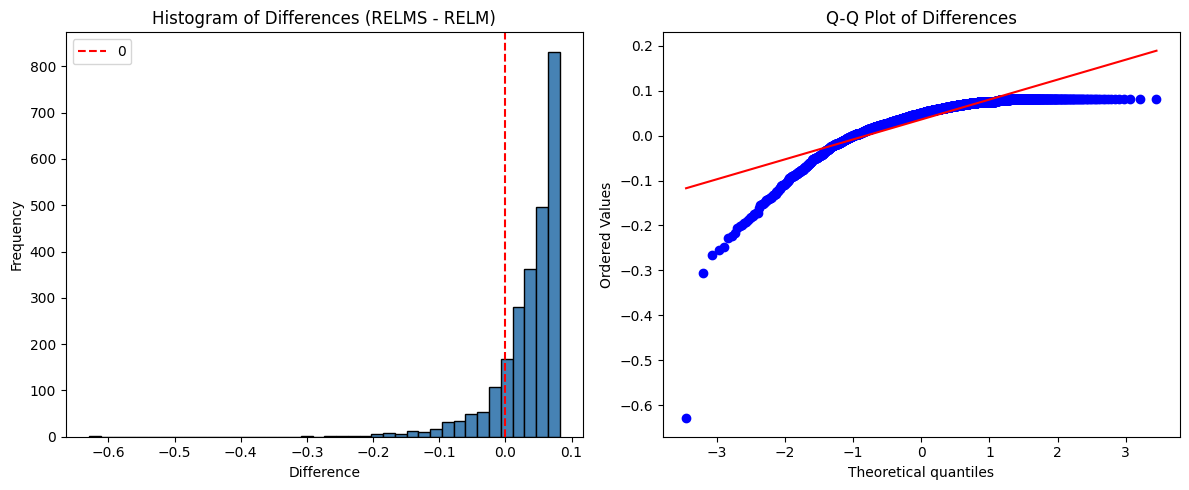

In [28]:
shapiro_stat, shapiro_p = stats.shapiro(diff)
print("\n--- Shapiro-Wilk normality test on differences ---")
print(f"W = {shapiro_stat:.4f}, p = {shapiro_p:.6f}")
if shapiro_p < 0.05:
    print("-> Differences deviate significantly from normality (favor Wilcoxon).")
else:
    print("-> No strong evidence against normality (paired t-test assumption reasonably met).")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(diff, bins=40, color="steelblue", edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--", label="0")
axes[0].set_title("Histogram of Differences (RELMS - RELM)")
axes[0].set_xlabel("Difference")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Q-Q plot
stats.probplot(diff, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Differences")

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/"inferential/relms_relm_diagnostics.png", dpi=150)
plt.show()

### Paired t-test (disregarding residuals non-normality)

In [29]:
t_stat, t_p = stats.ttest_rel(relms, relm)
cohens_d_paired = diff.mean() / diff.std(ddof=1)

print("\n--- Paired t-test ---")
print(f"t = {t_stat:.4f}, p = {t_p:.6f}")
print(f"Cohen's d (paired) = {cohens_d_paired:.4f}")


--- Paired t-test ---
t = 35.3013, p = 0.000000
Cohen's d (paired) = 0.7092


### Wilcoxon test

In [30]:
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(relms, relm)

# Matched-pairs rank-biserial correlation
nonzero_diff = diff[diff != 0]
n_nz = len(nonzero_diff)
ranks = stats.rankdata(np.abs(nonzero_diff))
pos_rank_sum = ranks[nonzero_diff > 0].sum()
neg_rank_sum = ranks[nonzero_diff < 0].sum()
total_rank_sum = pos_rank_sum + neg_rank_sum
rank_biserial = (pos_rank_sum - neg_rank_sum) / total_rank_sum

print("\n--- Wilcoxon signed-rank test ---")
print(f"W = {wilcoxon_stat:.4f}, p = {wilcoxon_p:.6f}")
print(f"Matched-pairs rank-biserial correlation = {rank_biserial:.4f}")



--- Wilcoxon signed-rank test ---
W = 411762.0000, p = 0.000000
Matched-pairs rank-biserial correlation = 0.7319


### Summary print and export to CSV

In [31]:
print("\n=== SUMMARY ===")
print(f"Paired t-test:  t={t_stat:.4f}, p={t_p:.6f}, Cohen's d={cohens_d_paired:.4f}")
print(f"Wilcoxon test:  W={wilcoxon_stat:.4f}, p={wilcoxon_p:.6f}, rank-biserial r={rank_biserial:.4f}")
print(f"Shapiro-Wilk normality check: W={shapiro_stat:.4f}, p={shapiro_p:.6f}")


=== SUMMARY ===
Paired t-test:  t=35.3013, p=0.000000, Cohen's d=0.7092
Wilcoxon test:  W=411762.0000, p=0.000000, rank-biserial r=0.7319
Shapiro-Wilk normality check: W=0.7700, p=0.000000


In [32]:
summary_dict = {'Paired t-test': f"t={t_stat:.4f}, p={t_p:.6f}, Cohen's d={cohens_d_paired:.4f}",
                'Wilcoxon test': f"W={wilcoxon_stat:.4f}, p={wilcoxon_p:.6f}, rank-biserial r={rank_biserial:.4f}",
                'Shapiro-Wilk normality check': f"W={shapiro_stat:.4f}, p={shapiro_p:.6f}"}
summary_series = pd.Series(summary_dict)
summary_df = summary_series.to_frame(name='Statistical Results')
summary_df.to_csv(RESULTS_DATA_DIR/"inferential/inferential_results.csv")